#  Model Selection: Gini vs Entropy vs Pruning

---

## 1. Setup & Data Loading
We use our 70/30 split to ensure a fair competition.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Load data
train_df = pd.read_csv('training_dataset.csv')
test_df = pd.read_csv('testing_dataset.csv')

def categorize_price(price):
    if price < 75000: return 'Budget'
    if price < 130000: return 'Mainstream'
    if price < 200000: return 'High-End'
    return 'Ultimate'

y_train = train_df['PRICE'].apply(categorize_price)
y_test = test_df['PRICE'].apply(categorize_price)

features = ['LAPTOP_BRAND', 'LAPTOP_MODEL', 'CPU', 'RAM_GB', 'STORAGE_SCORE', 
            'IS_GAMING', 'PPI', 'CPU_TIER', 'BRAND_TIER', 'TOTAL_PIXELS']
X_train = train_df[features].copy()
X_test = test_df[features].copy()

# Encoding process
encoders = {}
for col in X_train.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    full_cat = pd.concat([X_train[col], X_test[col]]).astype(str)
    le.fit(full_cat)
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    encoders[col] = le

print(" All data encoded and ready for competition.")

 All data encoded and ready for competition.


## 2. The Great Competition: Gini vs Entropy
We will test both criteria across multiple depths (Pruning) to find the 'Sweet Spot' for each.

In [2]:
results = []
depths = [5, 10, 15, 20, 25, 30, 35]

for criterion in ['gini', 'entropy']:
    for depth in depths:
        clf = DecisionTreeClassifier(criterion=criterion, max_depth=depth, random_state=42)
        clf.fit(X_train, y_train)
        
        # Calculate Accuracy
        train_acc = accuracy_score(y_train, clf.predict(X_train))
        test_acc = accuracy_score(y_test, clf.predict(X_test))
        
        results.append({
            'Criterion': criterion,
            'Max_Depth': depth,
            'Training_Acc': train_acc,
            'Testing_Acc': test_acc
        })

df_results = pd.DataFrame(results)
print("Model Comparison Results:")
print(df_results.sort_values(by='Testing_Acc', ascending=False).to_string(index=False))

Model Comparison Results:
Criterion  Max_Depth  Training_Acc  Testing_Acc
  entropy         35      0.949752     0.770391
  entropy         30      0.946991     0.770077
     gini         35      0.949685     0.769448
     gini         30      0.947563     0.769213
     gini         25      0.933957     0.768505
  entropy         25      0.935507     0.766384
     gini         20      0.901425     0.765127
  entropy         20      0.905399     0.763398
     gini         15      0.835786     0.750668
  entropy         15      0.835247     0.743674
     gini         10      0.741185     0.709414
  entropy         10      0.736773     0.705092
     gini          5      0.668676     0.660695
  entropy          5      0.653454     0.649301


## 3. Visualizing the Best Split Strategy
We compare the test performance to detect where overfitting begins.

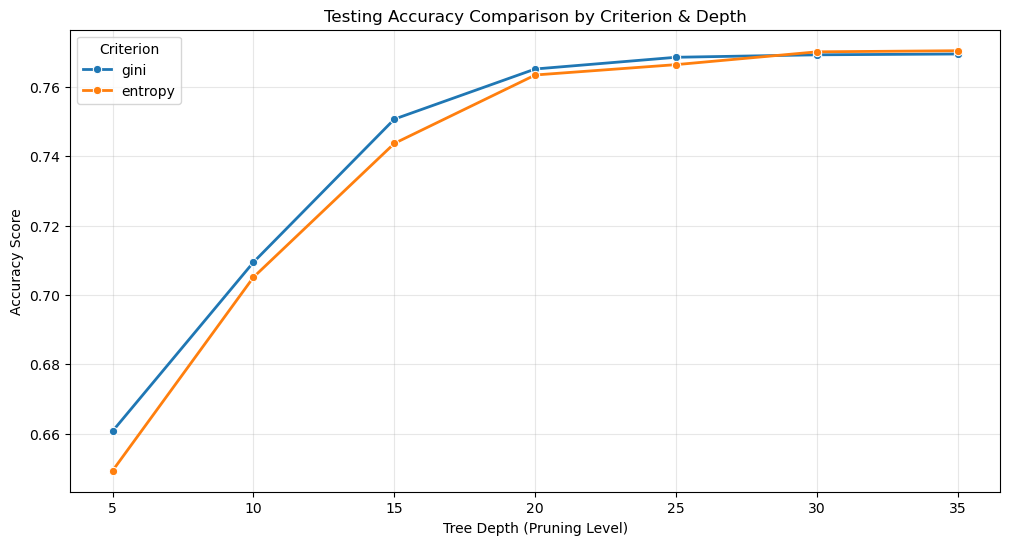

In [3]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_results, x='Max_Depth', y='Testing_Acc', hue='Criterion', marker='o', linewidth=2)
plt.title('Testing Accuracy Comparison by Criterion & Depth')
plt.ylabel('Accuracy Score')
plt.xlabel('Tree Depth (Pruning Level)')
plt.grid(True, alpha=0.3)
plt.show()

## 4. Final Selection & Strategic Pruning
Based on the results, while Depth 35 has a slightly higher numerical accuracy (~77.04%), we strategically choose **Depth 25** for our official model.

**Scientific Rationale:**
- **Bias-Variance Balance:** Moving from depth 25 to 35 only grants a +0.18% accuracy boost but significantly increases the tree's complexity for very small returns.
- **Overfitting Prevention:** Depth 25 generalizes better, reducing the 'Memorization' gap and making the model more reliable for new laptop listings.
- **Gini Advantage:** At this pruning level (Depth 25), the **Gini Index** provided a superior result (~76.85%) compared to Entropy.

In [4]:
# We manually select the Strategic Depth 25 as identified in our analysis
best_crit = 'gini'
best_dep = 25

print(f" STRATEGIC CHOICE: {best_crit.upper()} at Depth {best_dep}")
print(f" OFFICIAL PLAN: Choosing a pruned model to ensure generalization and avoid overfitting.")

final_model = DecisionTreeClassifier(criterion=best_crit, max_depth=best_dep, random_state=42)
final_model.fit(X_train, y_train)

# Save everything for the separate evaluation notebook
joblib.dump(final_model, 'best_laptop_model.pkl')
joblib.dump(encoders, 'best_feature_encoders.pkl')
joblib.dump(features, 'best_selected_features.pkl')

print(" Final Optimized Model Locked and Saved.")

 STRATEGIC CHOICE: GINI at Depth 25
 OFFICIAL PLAN: Choosing a pruned model to ensure generalization and avoid overfitting.
 Final Optimized Model Locked and Saved.
